# mCH–mCG covariation & sequence motifs (Fig S21)

Part of the **[Fig. 3 chapter](fig3.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{outdir}{ct}_1kb.hdf'`  ·  _other_
- `f'{outdir}{ct}_highCA_lowCG.stats.txt'`  ·  _other_
- `f'{outdir}{ct}_lowCA_lowCG.stats.txt'`  ·  _other_
- `f'{outdir}{ct}_highCA_lowCG/knownResults.txt'`  ·  _other_
- `f'{outdir}{ct}_lowCA_lowCG_vs_highCA_lowCG/knownResults.txt'`  ·  _other_
- `f'{outdir}{ct}_highCA_lowCG_vs_lowCA_lowCG/knownResults.txt'`  ·  _other_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed
from statsmodels.tsa.stattools import acf

import pysam
import cooler
import anndata
import scanpy as sc
from sklearn.cluster import KMeans

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/'
outdir = f'{indir}analysis/mCH_mCG_corr/'

In [4]:
# L1_list = np.sort([xx.split('/')[-1].split('.')[0] for xx in glob(f'{indir}merged_allc/L1/CHN/c*.allc.tsv.gz')])
# # L1_list = L1_list[L1_list!='Hema-B']
# L2_list = np.sort([xx.split('/')[-1].split('.')[0] for xx in glob(f'{indir}merged_allc/L2any/*.CGN-Merge.allc.tsv.gz')])
# print(len(L1_list), len(L2_list))
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35','c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()

In [5]:
ct = 'c5'
allc_path = f'{indir}merged_allc/L1/CHN/{ct}.allc.tsv.gz'


In [6]:
res = 1000

In [7]:
import cooler
chrom_size_path = f'{REF_ROOT}/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:23]


In [8]:
rm_list = []
for bed_path in [f'{REF_ROOT}/hg38/fasta/hg38.altseq.bed', f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz']:
    bed = pd.read_csv(bed_path, sep='\t', header=None, index_col=None)
    bed = {chrom:bed.loc[bed[0]==chrom, [1,2]].values for chrom in chrom_sizes.index}
    rm_list.append(bed)
    

In [9]:
chunks = cooler.util.binnify(chrom_sizes, 10000000)
context_list = pd.Index([f'C{xx}{yy}' for xx in 'ACGT' for yy in 'ACGT'])


In [10]:
def matrixch(allc_path, chrom, start, end):
    result_mc = {}
    result_cov = {}
    npos = (end - start) // res * res
    data = []
    # with gzip.open(allc_path, 'rt') as allc_lines:
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            data.append([pos, context, mc, cov])

    data = pd.DataFrame(data, columns=['pos', 'context', 'mc', 'cov'])
    data[['pos', 'mc', 'cov']] = data[['pos', 'mc', 'cov']].astype(int)
    posfilter = np.ones(data.shape[0]).astype(bool)
    for bed in rm_list:
        bedtmp = bed[chrom][np.logical_and(bed[chrom][:,0]<end, bed[chrom][:,1]>start)]
        for xx,yy in bedtmp:
            posfilter[np.logical_and(data['pos']>=xx, data['pos']<=yy)] = False

    data = data.loc[posfilter & ((data['pos']-start) < npos)]
    data = data.groupby('context')
    for k,context in enumerate(context_list):
        if not context in data.groups.keys():
            result_mc[context] = np.zeros(npos//res)
            result_cov[context] = np.zeros(npos//res)
            continue
        df = data.get_group(context)
        data_mc = csr_matrix((df['mc'], (np.zeros(df.shape[0]), df['pos']-start-1)), shape=[1, npos])
        data_cov = csr_matrix((df['cov'], (np.zeros(df.shape[0]), df['pos']-start-1)), shape=[1, npos])
        result_mc[context] = data_mc.reshape((-1, res)).sum(axis=1).A1
        result_cov[context] = data_cov.reshape((-1, res)).sum(axis=1).A1
        
    return pd.DataFrame(result_mc), pd.DataFrame(result_cov)
    

In [11]:
cpu = 24
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for i,(chrom,start,end) in enumerate(chunks[['chrom','start','end']].values[:100]):
        future = executor.submit(
            matrixch,
            allc_path=allc_path, 
            chrom=chrom, 
            start=int(start), 
            end=int(end)
        )
        futures[future] = i

    result_mc = {}
    result_cov = {}
    for future in as_completed(futures):
        idx = futures[future]
        mc, cov = future.result()
        result_mc[idx] = mc
        result_cov[idx] = cov
        print(f'chunk{idx} finished')
                
# result_mc = pd.concat([result_mc[i] for i in range(len(chunks))], axis=0, ignore_index=True)
# result_cov = pd.concat([result_cov[i] for i in range(len(chunks))], axis=0, ignore_index=True)
# result_mc.to_hdf(f'mCH_mCG_corr/{ct}_1kb.hdf', key='mc')
# result_cov.to_hdf(f'mCH_mCG_corr/{ct}_1kb.hdf', key='cov')


In [12]:
result_mc = pd.concat([result_mc[i] for i in range(100)], axis=0, ignore_index=True)
result_cov = pd.concat([result_cov[i] for i in range(100)], axis=0, ignore_index=True)
print(result_mc.shape, result_cov.shape)

In [13]:
context_dict = {'CA': ['CAA', 'CAC', 'CAG', 'CAT', 'CTC'], 
                 'CC': ['CCA', 'CCC', 'CCG', 'CCT'], 
                 'CG': ['CGA', 'CGC', 'CGG', 'CGT'], 
                 'CT': ['CTA', 'CTG', 'CTT']}
context_group = {context: k for k,v in context_dict.items() for context in v}

In [14]:
import numpy as np

def tls_outliers_mad(x, y, z=6.0):
    """
    Orthogonal regression (total least squares) + robust threshold on perpendicular distance.

    Parameters
    ----------
    x, y : array-like, shape (n,)
    z : float
        Outlier cutoff in robust-sigma units. 5-8 is a common range; 6 is a good start.

    Returns
    -------
    outlier_idx : 1D int array
        Indices (in the original input arrays) flagged as outliers.
    dist : 1D float array
        Perpendicular distances for valid points (finite x and y), same order as valid_idx.
    info : dict
        Contains line params and robust stats.
    """
    x = np.asarray(x)
    y = np.asarray(y)

    valid = np.isfinite(x) & np.isfinite(y)
    valid_idx = np.flatnonzero(valid)
    xv = x[valid]
    yv = y[valid]

    # --- TLS fit via PCA/SVD on centered data ---
    mx, my = xv.mean(), yv.mean()
    X = np.column_stack((xv - mx, yv - my))  # (n, 2)

    # principal direction (first right-singular vector)
    # vt[0] is direction in (x,y); unit length
    _, _, vt = np.linalg.svd(X, full_matrices=False)
    vx, vy = vt[0]

    # line in normal form: n·(p - mu)=0, where n is perpendicular to direction v
    # choose unit normal
    nx, ny = -vy, vx

    # perpendicular distance to TLS line: |n·(p - mu)|
    dist = np.abs(nx * (xv - mx) + ny * (yv - my))  # n is unit-length

    # --- robust scale & threshold ---
    med = np.median(dist)
    mad = np.median(np.abs(dist - med))
    sigma = 1.4826 * mad  # MAD->sigma for normal, robust
    if sigma == 0:  # degenerate case: almost all points exactly on line
        sigma = dist.std() + 1e-12

    out_mask = dist > (med + z * sigma)
    outlier_idx = valid_idx[out_mask]

    info = {
        "mu": (mx, my),
        "direction": (vx, vy),
        "normal": (nx, ny),
        "median_dist": float(med),
        "mad": float(mad),
        "robust_sigma": float(sigma),
        "z": float(z),
        "n_valid": int(dist.size),
        "n_outliers": int(out_mask.sum()),
    }
    return outlier_idx, dist, info


In [15]:
import numpy as np
import statsmodels.api as sm

def quantile_outliers(x, y, q=0.99, sample=200_000, seed=0):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x0 = x[m]; y0 = y[m]

    rng = np.random.default_rng(seed)
    idx = rng.choice(x0.size, size=min(sample, x0.size), replace=False)
    Xs = sm.add_constant(x0[idx])
    mod = sm.QuantReg(y0[idx], Xs).fit(q=q)

    yhat_q = mod.predict(sm.add_constant(x0))
    out = y0 > yhat_q
    out_idx = np.flatnonzero(m)[out]
    return out_idx, mod


In [16]:
import numpy as np
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer
from sklearn.linear_model import Ridge
from sklearn.mixture import GaussianMixture

def fit_conditional_outliers_gmm(x, y, spline_df=30, ridge=1.0, subsample=300_000, seed=0):
    """
    Returns indices for: high-CA outliers, low-CA outliers, and inliers,
    using a heteroscedastic model + GMM on standardized residuals.

    No manual thresholds on distance/percentile.
    """
    x = np.asarray(x); y = np.asarray(y)
    valid = np.isfinite(x) & np.isfinite(y)
    xv = x[valid]
    yv = y[valid]
    orig_idx = np.flatnonzero(valid)

    # Subsample for fitting (keeps things fast on 1M+)
    rng = np.random.default_rng(seed)
    n = xv.size
    fit_n = min(subsample, n)
    fit_idx = rng.choice(n, size=fit_n, replace=False)

    X_fit = xv[fit_idx].reshape(-1, 1)
    y_fit = yv[fit_idx]

    # 1) mean model mu(x)
    mean_model = make_pipeline(
        SplineTransformer(n_knots=spline_df, degree=3, include_bias=False),
        Ridge(alpha=ridge)
    )
    mean_model.fit(X_fit, y_fit)

    mu = mean_model.predict(xv.reshape(-1, 1))
    resid = yv - mu

    # 2) variance model sigma(x): fit log(resid^2) ~ spline(x)
    #    (robust-ish: add epsilon, and clip extremes)
    eps = 1e-12
    r2 = resid**2 + eps
    lr2 = np.log(r2)

    var_model = make_pipeline(
        SplineTransformer(n_knots=spline_df, degree=3, include_bias=False),
        Ridge(alpha=ridge)
    )
    var_model.fit(X_fit, lr2[fit_idx])

    log_sigma2 = var_model.predict(xv.reshape(-1, 1))
    sigma = np.sqrt(np.exp(log_sigma2))
    sigma = np.maximum(sigma, np.median(sigma) * 1e-3)  # avoid pathological tiny sigma

    # 3) standardized residual
    z = (resid / sigma).reshape(-1, 1)

    # 4) GMM on z (3 components: inlier, high, low)
    gmm = GaussianMixture(n_components=3, random_state=seed)
    gmm.fit(z[fit_idx])

    labels = gmm.predict(z)
    means = gmm.means_.ravel()

    inlier_comp = np.argmin(np.abs(means))  # closest to 0
    high_comp = np.argmax(means)            # positive outliers
    low_comp  = np.argmin(means)            # negative outliers

    high_idx = orig_idx[labels == high_comp]
    low_idx  = orig_idx[labels == low_comp]
    inl_idx  = orig_idx[labels == inlier_comp]

    info = {
        "component_means_z": means,
        "inlier_comp": int(inlier_comp),
        "high_comp": int(high_comp),
        "low_comp": int(low_comp),
        "weights": gmm.weights_.ravel(),
    }
    return high_idx, low_idx, inl_idx, info


In [17]:
import numpy as np
from sklearn.mixture import GaussianMixture

def bh_fdr(p, q=0.01):
    """Return boolean mask of discoveries using Benjamini–Hochberg at FDR q."""
    p = np.asarray(p)
    m = p.size
    order = np.argsort(p)
    p_sorted = p[order]
    thresh = q * (np.arange(1, m + 1) / m)
    ok = p_sorted <= thresh
    if not np.any(ok):
        return np.zeros_like(p, dtype=bool)
    k = np.max(np.where(ok)[0])
    cutoff = p_sorted[k]
    return p <= cutoff

def conditional_tail_outliers(x, y, nbins=400, min_bin=200, q=0.01, seed=0):
    """
    CG-aware outliers:
      - lowCG_highCA: CA unusually high given CG and CG in low mode
      - highCG_lowCA: CA unusually low given CG and CG in high mode

    Uses:
      - data-driven low/high CG split via 2-component GMM on CG
      - empirical conditional CDF within CG bins
      - BH-FDR to call significant tail events (statistical control)
    """
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    orig_idx = np.flatnonzero(m)
    n = x.size

    # --- data-driven split of CG into low/high regimes ---
    g = GaussianMixture(n_components=2, random_state=seed)
    g.fit(x.reshape(-1, 1))
    comp = g.predict(x.reshape(-1, 1))
    means = g.means_.ravel()
    low_comp = np.argmin(means)
    high_comp = np.argmax(means)
    is_lowCG = comp == low_comp
    is_highCG = comp == high_comp

    # --- bin CG ---
    edges = np.linspace(x.min(), x.max(), nbins + 1)
    b = np.searchsorted(edges, x, side="right") - 1
    b = np.clip(b, 0, nbins - 1)

    # sort by bin for grouped processing
    order = np.argsort(b)
    b_s, y_s = b[order], y[order]
    starts = np.r_[0, np.flatnonzero(np.diff(b_s)) + 1]
    ends   = np.r_[starts[1:], n]

    # We'll compute p_high and p_low for each point (in sorted order)
    p_high = np.full(n, np.nan)
    p_low  = np.full(n, np.nan)

    # For each bin: compute empirical CDF efficiently using ranks
    for s, e in zip(starts, ends):
        if e - s < min_bin:
            continue
        ys = y_s[s:e]
        # ranks: for each y, how many <= y?
        # Use sorting once per bin
        ys_sorted = np.sort(ys)
        # F(y) = #(<=y)/m
        r = np.searchsorted(ys_sorted, ys, side="right")
        F = r / (e - s)
        p_low[order[s:e]] = F
        p_high[order[s:e]] = 1.0 - F

    # drop points from tiny bins (nan p-values)
    ok = np.isfinite(p_high) & np.isfinite(p_low)
    x2, y2 = x[ok], y[ok]
    idx2 = orig_idx[ok]
    is_lowCG2 = is_lowCG[ok]
    is_highCG2 = is_highCG[ok]
    p_high2 = p_high[ok]
    p_low2  = p_low[ok]

    # --- apply BH-FDR within each hypothesis family ---
    # lowCG/highCA -> upper-tail in lowCG mode
    selA = is_lowCG2
    discA = np.zeros_like(selA, dtype=bool)
    if np.any(selA):
        discA[selA] = bh_fdr(p_high2[selA], q=q)

    # highCG/lowCA -> lower-tail in highCG mode
    selB = is_highCG2
    discB = np.zeros_like(selB, dtype=bool)
    if np.any(selB):
        discB[selB] = bh_fdr(p_low2[selB], q=q)

    return {
        "lowCG_highCA": idx2[discA],
        "highCG_lowCA": idx2[discB],
        "meta": {
            "nbins": nbins, "min_bin": min_bin, "fdr_q": q,
            "cg_means": means,
            "n_used": int(idx2.size),
            "n_lowCG_highCA": int(discA.sum()),
            "n_highCG_lowCA": int(discB.sum()),
        }
    }


In [18]:
import numpy as np

def robust_bin_outliers(x, y, nbins=400, min_bin=200, k_clip=6.0, z=6.0, n_iter=2):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]; y = y[m]
    orig_idx = np.flatnonzero(m)

    edges = np.linspace(x.min(), x.max(), nbins + 1)
    b = np.searchsorted(edges, x, side="right") - 1
    b = np.clip(b, 0, nbins - 1)

    order = np.argsort(b)
    b_s, y_s = b[order], y[order]
    starts = np.r_[0, np.flatnonzero(np.diff(b_s)) + 1]
    ends   = np.r_[starts[1:], y_s.size]

    out = np.zeros(y_s.size, dtype=bool)

    for s, e in zip(starts, ends):
        if e - s < min_bin:
            continue
        ys = y_s[s:e].copy()

        # iterative robust fit
        for _ in range(n_iter):
            med = np.median(ys)
            mad = np.median(np.abs(ys - med))
            sigma = 1.4826 * mad
            if sigma <= 0:
                break
            lo = med - k_clip * sigma
            hi = med + k_clip * sigma
            ys = np.clip(ys, lo, hi)

        # final score on original (unclipped) values
        med = np.median(ys)
        mad = np.median(np.abs(ys - med))
        sigma = 1.4826 * mad
        if sigma <= 0:
            continue

        out[s:e] = np.abs(y_s[s:e] - med) > (z * sigma)

    out_idx = orig_idx[order[out]]
    return out_idx, edges


In [19]:
import numpy as np
import statsmodels.api as sm
from patsy import dmatrix
from sklearn.mixture import GaussianMixture

def split_low_high_cg(x, seed=0):
    x = np.asarray(x)
    g = GaussianMixture(n_components=2, random_state=seed).fit(x.reshape(-1, 1))
    comp = g.predict(x.reshape(-1, 1))
    means = g.means_.ravel()
    low_comp = np.argmin(means)
    high_comp = np.argmax(means)
    return (comp == low_comp), (comp == high_comp), {"cg_means": means, "cg_weights": g.weights_}

def quantreg_spline_outliers(x, y, q_low=0.01, q_high=0.99,
                             df_spline=10, subsample=300_000, seed=0,
                             grid_size=500):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    xv = x[m]; yv = y[m]
    orig_idx = np.flatnonzero(m)

    # low/high CG modes (data-driven)
    is_lowCG, is_highCG, cg_info = split_low_high_cg(xv, seed=seed)

    # subsample for fitting
    rng = np.random.default_rng(seed)
    n = xv.size
    fit_n = min(subsample, n)
    fit_idx = rng.choice(n, size=fit_n, replace=False)

    x_fit = xv[fit_idx]
    y_fit = yv[fit_idx]

    # spline design matrix via patsy (natural cubic regression spline)
    # You can increase df_spline if curvature is strong.
    X_fit = dmatrix(f"cr(x, df={df_spline})", {"x": x_fit}, return_type="dataframe")
    X_all = dmatrix(f"cr(x, df={df_spline})", {"x": xv}, return_type="dataframe")

    # fit quantile regressions
    mod_low = sm.QuantReg(y_fit, X_fit).fit(q=q_low)
    mod_high = sm.QuantReg(y_fit, X_fit).fit(q=q_high)

    ql = np.asarray(mod_low.predict(X_all))
    qh = np.asarray(mod_high.predict(X_all))

    # classify corners (no percentile choice; using model quantiles)
    lowCG_highCA = is_lowCG & (yv > qh)
    highCG_lowCA = is_highCG & (yv < ql)

    # envelope for plotting on a grid
    xg = np.linspace(xv.min(), xv.max(), grid_size)
    Xg = dmatrix(f"cr(x, df={df_spline})", {"x": xg}, return_type="dataframe")
    ql_g = np.asarray(mod_low.predict(Xg))
    qh_g = np.asarray(mod_high.predict(Xg))

    return {
        "lowCG_highCA": orig_idx[lowCG_highCA],
        "highCG_lowCA": orig_idx[highCG_lowCA],
        "envelope": {"x_grid": xg, "q_low": ql_g, "q_high": qh_g},
        "models": {"low": mod_low, "high": mod_high},
        "meta": {"q_low": q_low, "q_high": q_high, "df_spline": df_spline, **cg_info}
    }

import numpy as np
from scipy.ndimage import gaussian_filter1d

def robust_binned_outliers(x, y, nbins=400, min_bin=200,
                           k_trim=6.0,  # trim using median ± k*MAD within bin
                           z_env=3.0,   # envelope width in sigma units after trimming
                           smooth_sigma_bins=2.0,
                           seed=0):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    xv = x[m]; yv = y[m]
    orig_idx = np.flatnonzero(m)

    # low/high CG modes (data-driven)
    is_lowCG, is_highCG, cg_info = split_low_high_cg(xv, seed=seed)

    # bin CG
    edges = np.linspace(xv.min(), xv.max(), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    b = np.searchsorted(edges, xv, side="right") - 1
    b = np.clip(b, 0, nbins - 1)

    # arrays for per-bin envelope
    q_low_bin = np.full(nbins, np.nan)
    q_high_bin = np.full(nbins, np.nan)
    counts = np.bincount(b, minlength=nbins)

    # compute robust envelope per bin
    for bi in range(nbins):
        if counts[bi] < min_bin:
            continue
        ys = yv[b == bi]
        med = np.median(ys)
        mad = np.median(np.abs(ys - med))
        sigma = 1.4826 * mad
        if sigma <= 0:
            continue

        # trim presumed outliers to avoid masking
        keep = (ys >= med - k_trim * sigma) & (ys <= med + k_trim * sigma)
        ys2 = ys[keep]
        if ys2.size < min_bin:
            continue

        med2 = np.median(ys2)
        mad2 = np.median(np.abs(ys2 - med2))
        sigma2 = 1.4826 * mad2
        if sigma2 <= 0:
            continue

        q_low_bin[bi] = med2 - z_env * sigma2
        q_high_bin[bi] = med2 + z_env * sigma2

    # fill missing bins by interpolation (then smooth)
    good = np.isfinite(q_low_bin) & np.isfinite(q_high_bin)
    if good.sum() >= 5:
        q_low_bin = np.interp(np.arange(nbins), np.flatnonzero(good), q_low_bin[good])
        q_high_bin = np.interp(np.arange(nbins), np.flatnonzero(good), q_high_bin[good])

        if smooth_sigma_bins and smooth_sigma_bins > 0:
            q_low_bin = gaussian_filter1d(q_low_bin, sigma=smooth_sigma_bins, mode="nearest")
            q_high_bin = gaussian_filter1d(q_high_bin, sigma=smooth_sigma_bins, mode="nearest")

    # assign envelope per point by its bin
    ql = q_low_bin[b]
    qh = q_high_bin[b]

    lowCG_highCA = is_lowCG & (yv > qh)
    highCG_lowCA = is_highCG & (yv < ql)

    return {
        "lowCG_highCA": orig_idx[lowCG_highCA],
        "highCG_lowCA": orig_idx[highCG_lowCA],
        "envelope": {"x_grid": centers, "q_low": q_low_bin, "q_high": q_high_bin, "bin_edges": edges},
        "meta": {"nbins": nbins, "min_bin": min_bin, "k_trim": k_trim, "z_env": z_env,
                 "smooth_sigma_bins": smooth_sigma_bins, **cg_info}
    }


In [20]:
import numpy as np

def robust_bin_outliers_signed(x, y, nbins=400, min_bin=200, k_clip=10.0, z=10.0, n_iter=2):
    x = np.asarray(x); y = np.asarray(y)
    m = np.isfinite(x) & np.isfinite(y)
    xv = x[m]; yv = y[m]
    orig_idx = np.flatnonzero(m)

    edges = np.linspace(xv.min(), xv.max(), nbins + 1)
    b = np.searchsorted(edges, xv, side="right") - 1
    b = np.clip(b, 0, nbins - 1)

    order = np.argsort(b)
    b_s, y_s = b[order], yv[order]
    starts = np.r_[0, np.flatnonzero(np.diff(b_s)) + 1]
    ends   = np.r_[starts[1:], y_s.size]

    z_rob = np.full(y_s.size, np.nan)
    hi = np.zeros(y_s.size, dtype=bool)
    lo = np.zeros(y_s.size, dtype=bool)

    for s, e in zip(starts, ends):
        if e - s < min_bin:
            continue

        ys = y_s[s:e].copy()

        # iterative robust fit with winsorization
        for _ in range(n_iter):
            med = np.median(ys)
            mad = np.median(np.abs(ys - med))
            sigma = 1.4826 * mad
            if sigma <= 0:
                break
            ys = np.clip(ys, med - k_clip * sigma, med + k_clip * sigma)

        med = np.median(ys)
        mad = np.median(np.abs(ys - med))
        sigma = 1.4826 * mad
        if sigma <= 0:
            continue

        zr = (y_s[s:e] - med) / sigma
        z_rob[s:e] = zr
        hi[s:e] = zr > z
        lo[s:e] = zr < -z

    # map back to original indexing
    idx_sorted = orig_idx[order]
    return {
        "high_outliers": idx_sorted[hi],   # unusually high CA given CG bin
        "low_outliers": idx_sorted[lo],    # unusually low CA given CG bin
        "z_robust_sorted": z_rob,          # aligned with idx_sorted
        "idx_sorted": idx_sorted,
        "bin_edges": edges,
    }


In [21]:
ct = 'c10'
mc = pd.read_hdf(f'{outdir}{ct}_1kb.hdf', key='mc').groupby(context_group, axis=1).sum()
cov = pd.read_hdf(f'{outdir}{ct}_1kb.hdf', key='cov').groupby(context_group, axis=1).sum()

In [22]:
binfilter = ((cov>10).sum(axis=1)==4)
print(binfilter.sum(), binfilter.shape[0])
ratio = mc / cov
ratio = ratio.loc[binfilter]

In [23]:
imprint_bed = pd.read_csv(f'{outdir}ICR.bed', header=None, sep='\t', index_col=None, names=['chrom','start','end'])
imprint_bed.index = imprint_bed['chrom'] + '-' + ((imprint_bed['start']+imprint_bed['end'])//2//res).astype(str)


In [24]:
from scipy.stats import rankdata
def norm(s):
    lo, hi = s.quantile([0.001, 0.999])
    s_norm = (s.clip(lo, hi) - lo) / (hi - lo)
    return s_norm

idx = np.arange(ratio.shape[0])
xx = ratio['CA'].clip
order = rankdata(norm(ratio['CA']) + norm(-ratio['CG']))
result = {'low_outliers': idx[order<2000], 
          'high_outliers': idx[order>(len(ratio)-2000)]}

In [25]:
# out_idx, edges = robust_bin_outliers(ratio['CG'], ratio['CA'])
# out_idx, mod = quantile_outliers(ratio['CG'], ratio['CA'])
result = robust_bin_outliers_signed(ratio['CG'], ratio['CA'])


In [26]:
bed = cooler.util.binnify(chrom_sizes, res)
bed = bed.loc[bed['end']-bed['start']==res].reset_index(drop=True)
bed['name'] = bed['chrom'].astype(str) + '-' + (bed['start']//res).astype(str)
bed = bed.loc[binfilter].reset_index(drop=True)

out_idx = bed.reset_index().index[bed['name'].isin(imprint_bed.index)]
print(len(out_idx))

In [27]:
from matplotlib.colors import LogNorm

x = ratio["CG"].to_numpy()
y = ratio["CA"].to_numpy()

# 2D histogram
H, xedges, yedges = np.histogram2d(x, y, bins=100)

fig, ax = plt.subplots()
m = ax.pcolormesh(
    xedges, yedges, H.T,
    cmap='Reds',
    norm=LogNorm(vmin=1),  # log color scale
    shading="auto"
)
idx_high = result['high_outliers']
ax.scatter(
    x[idx_high], y[idx_high],
    s=0.5, c='b', label='lowCG_highCA'
)
idx_low = result['low_outliers']
ax.scatter(
    x[idx_low], y[idx_low],
    s=0.5, c='g', label='highCG_lowCA'
)
# ax.scatter(
#     x[out_idx], y[out_idx],
#     s=0.5, c='k', label='outliers'
# )
fig.colorbar(m, ax=ax, label="count")
ax.set_xlabel("CG")
ax.set_ylabel("CA")



In [28]:
from matplotlib.colors import LogNorm

x = ratio["CG"].to_numpy()
y = ratio["CA"].to_numpy()

# 2D histogram
H, xedges, yedges = np.histogram2d(x, y, bins=100)

fig, ax = plt.subplots()
m = ax.pcolormesh(
    xedges, yedges, H.T,
    cmap='Reds',
    norm=LogNorm(vmin=1),  # log color scale
    shading="auto"
)
idx_high = result['high_outliers']
ax.scatter(
    x[idx_high], y[idx_high],
    s=0.5, c='b', label='lowCG_highCA'
)
idx_low = result['low_outliers']
ax.scatter(
    x[idx_low], y[idx_low],
    s=0.5, c='g', label='highCG_lowCA'
)
ax.scatter(
    x[out_idx], y[out_idx],
    s=0.5, c='k', label='outliers'
)
fig.colorbar(m, ax=ax, label="count")
ax.set_xlabel("CG")
ax.set_ylabel("CA")



In [29]:
global_cg = mc['CG'].sum() / cov['CG'].sum()

bed.loc[(ratio['CG']<0.2) & (bed.index.isin(bed.index[result['high_outliers']]))].sort_values(['chrom','start']).to_csv(f'{outdir}{ct}_highCA_lowCG.bed', sep='\t', header=False, index=False)
# bed.loc[(ratio['CG']>global_cg) & (bed.index.isin(bed.index[result['high_outliers']]))].sort_values(['chrom','start']).to_csv(f'{outdir}{ct}_highCA_highCG.bed', sep='\t', header=False, index=False)


In [30]:
import os
ct = 'c10'
cmd = f'bedtools intersect -wa -a {REF_ROOT}/hg38/gencode/v30/gencode.v30.annotation.gene.sorted.bed.gz -b {outdir}{ct}_highCA_lowCG.bed | cut -f4 | cut -d. -f1 | sort | uniq > {outdir}{ct}_highCA_lowCG.genebody.txt'
os.system(cmd)

In [31]:
result = {}
for ct in L1_meta.index:
    stats_high = pd.read_csv(f'{outdir}{ct}_highCA_lowCG.stats.txt', sep='\t', header=0, index_col=0, nrows=13)
    stats_low = pd.read_csv(f'{outdir}{ct}_lowCA_lowCG.stats.txt', sep='\t', header=0, index_col=0, nrows=13)
    tmp = pd.DataFrame([stats_high['Number of peaks'], stats_low['Number of peaks']], index=['highCA_lowCG', 'lowCA_lowCG']).T
    tmp = tmp / tmp.sum(axis=0)
    result[ct] = np.log2(tmp['highCA_lowCG']/tmp['lowCA_lowCG'])

result = pd.DataFrame(result).fillna(0)
result = result.loc[result.std(axis=1)>0].T

In [32]:
cg = sns.clustermap(result, cmap='bwr', vmin=-3, vmax=3, metric='cosine', yticklabels=result.index.map(L1_annot), figsize=(5,5))
rorder = cg.dendrogram_row.reordered_ind
corder = cg.dendrogram_col.reordered_ind

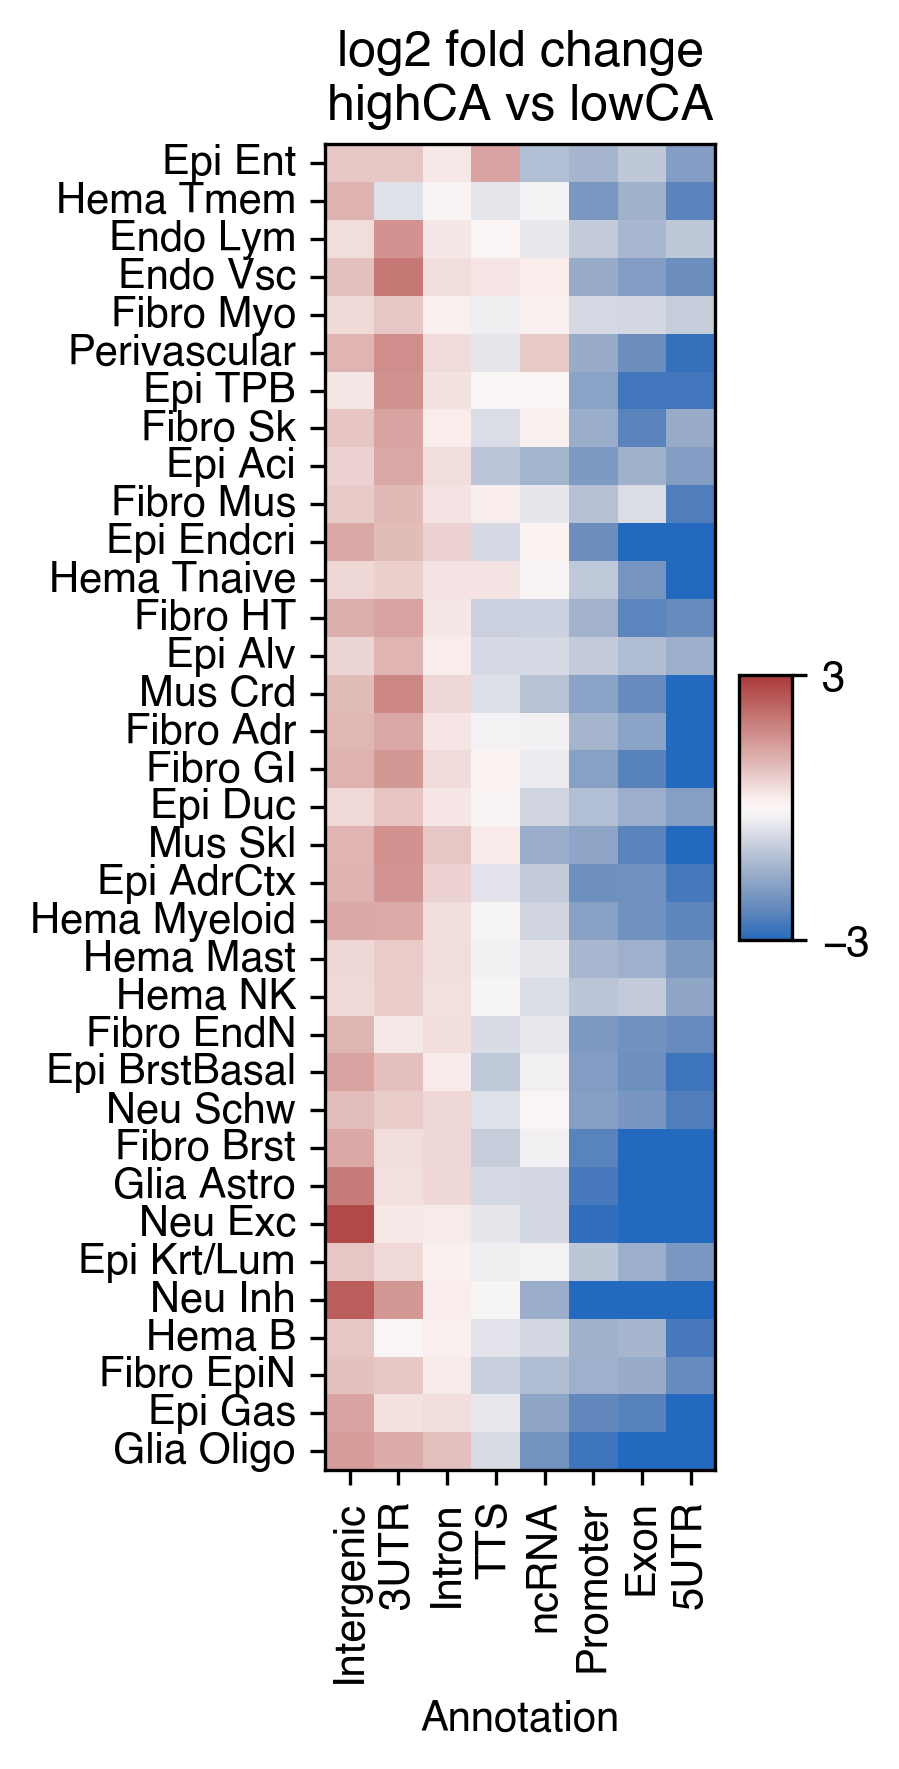

In [33]:
fig, ax = plt.subplots(figsize=(3,6), dpi=300)
sns.heatmap(result.iloc[rorder, corder],
            yticklabels=result.index.map(L1_annot)[rorder],
            cmap='vlag', ax=ax, vmin=-3, vmax=3,
            cbar_kws={"shrink": 0.2, "aspect": 5, "ticks": [-3, 3]})
sns.despine(ax=ax, top=False, right=False, left=False, bottom=False)
# ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
ax.set_title('log2 fold change\nhighCA vs lowCA')
cbar = ax.collections[0].colorbar
cbar.ax.spines['outline'].set_linewidth(0.8)
fig.tight_layout()
fig.savefig(f'mCH_mCG_corr/highCA_lowCG_lowCA_lowCG_annot_fc.pdf', transparent=True)


In [34]:
result = {}
for ct in L1_meta.index:
    tmp = pd.read_csv(f'{outdir}{ct}_highCA_lowCG/knownResults.txt', sep='\t', header=0, index_col=0)
    # low_cg = pd.read_csv(f'{outdir}{ct}_lowCA_lowCG_vs_highCA_lowCG/knownResults.txt', sep='\t', header=0, index_col=0)
    result[ct] = -tmp.loc[~tmp.index.duplicated(), 'Log P-value']

result = pd.DataFrame(result).fillna(0)
result = result.loc[(result>5).sum(axis=1)>10].T
result.columns = result.columns.str.split('/').str[0]


In [35]:
result = {}
for ct in L1_meta.index:
    tmp = pd.read_csv(f'{outdir}{ct}_lowCA_lowCG_vs_highCA_lowCG/knownResults.txt', sep='\t', header=0, index_col=0)
    result[ct] = -tmp.loc[~tmp.index.duplicated(), 'Log P-value']

result = pd.DataFrame(result).fillna(0)
result = result.loc[(result>5).sum(axis=1)>2].T
result.columns = result.columns.str.split('/').str[0]


In [36]:
cg = sns.clustermap(result, vmin=5, vmax=20, cmap='cividis', metric='cosine', figsize=(18,8), 
               xticklabels=4, 
               yticklabels=result.index.map(L1_annot))
rorder = cg.dendrogram_row.reordered_ind
corder = cg.dendrogram_col.reordered_ind
result_hypo = result.iloc[rorder, corder]

In [37]:
result = {}
for ct in L1_meta.index:
    tmp = pd.read_csv(f'{outdir}{ct}_highCA_lowCG_vs_lowCA_lowCG/knownResults.txt', sep='\t', header=0, index_col=0)
    # low_cg = pd.read_csv(f'{outdir}{ct}_lowCA_lowCG_vs_highCA_lowCG/knownResults.txt', sep='\t', header=0, index_col=0)
    result[ct] = -tmp.loc[~tmp.index.duplicated(), 'Log P-value']

result = pd.DataFrame(result).fillna(0)
result = result.loc[(result>5).sum(axis=1)>2].T
result.columns = result.columns.str.split('/').str[0]


In [38]:
cg = sns.clustermap(result.loc[result_hypo.index], 
                    vmin=5, vmax=20, cmap='cividis', metric='cosine', 
                    row_cluster=False, figsize=(18,8), 
                    xticklabels=2, yticklabels=result_hypo.index.map(L1_annot))
# rorder = cg.dendrogram_row.reordered_ind
corder = cg.dendrogram_col.reordered_ind
result_hyper = result.iloc[rorder, corder]

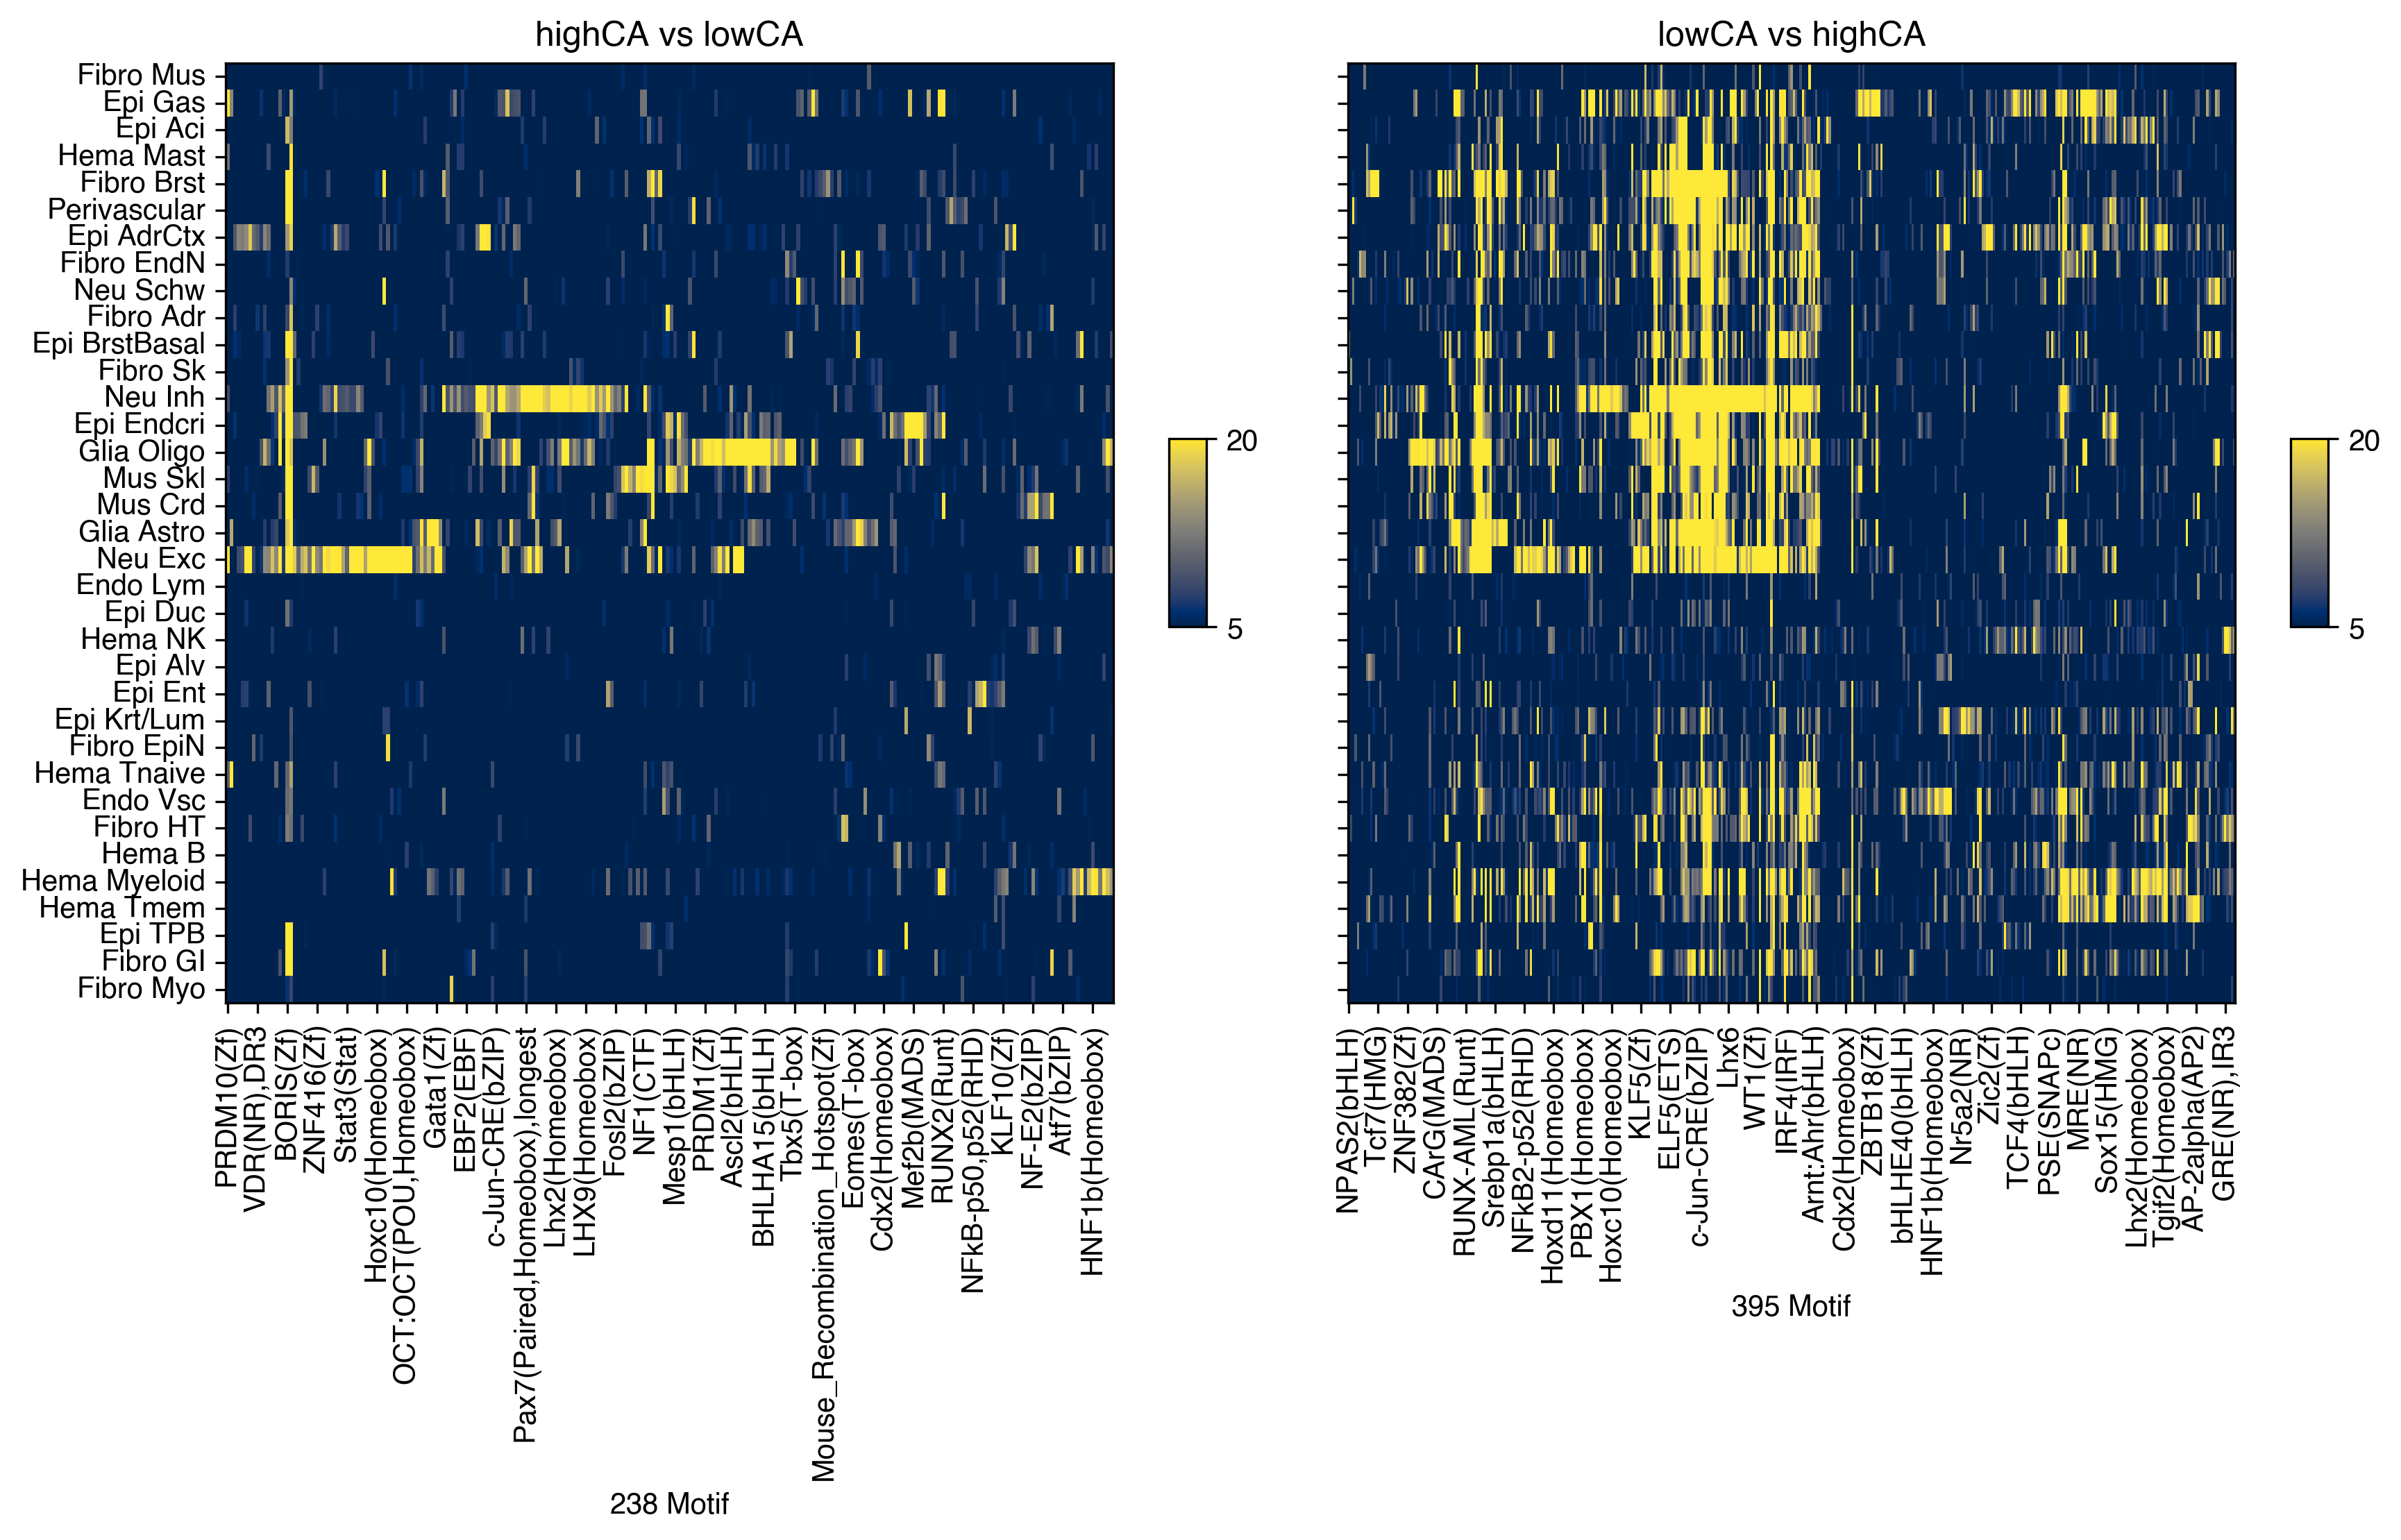

In [39]:
vmin, vmax = 5, 20
fig, axes = plt.subplots(1, 2, figsize=(12,7.5), sharey='all', dpi=300)
for i, result in enumerate([result_hyper, result_hypo]):
    ax = axes[i]
    sns.heatmap(result,
                yticklabels=result.index.map(L1_annot), xticklabels=result.shape[1]//29,
                rasterized=True, cmap='cividis', ax=ax, vmin=vmin, vmax=vmax,
                cbar_kws={"shrink": 0.2, "aspect": 5, "ticks": [vmin, vmax]})
    sns.despine(ax=ax, top=False, right=False, left=False, bottom=False)
    # ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.set_xlabel(f'{result.shape[1]} Motif')
    ax.set_title(['highCA vs lowCA', 'lowCA vs highCA'][i])
    cbar = ax.collections[0].colorbar
    cbar.ax.spines['outline'].set_linewidth(0.8)

fig.tight_layout()
fig.savefig(f'mCH_mCG_corr/lowCG_highCA_vs_lowCA_motif_pvalue.pdf', transparent=True)
